## Project 2: Structured Data Agent (Text-to-SQL + Text-to-Pandas)  
**What to build:** An agent that accepts natural language questions about a dataset (e.g., a public industrial or financial dataset), decides whether to generate SQL (for a database) or Pandas code (for a CSV)*-the decision should primarily be driven by the data source type, not by the content of the user's question-*, executes the code in a sandboxed environment, inspects the result, and self-corrects if execution fails.

**Why it matters:** Text-to-SQL is one of the most-requested agentic patterns in enterprise settings. This is about of Learning LangChain (Query Construction → Text-to-SQL section) and is heavily used in the data engineering / ETL pipeline work that target roles  require.

**Tech stack:** LangChain SQL toolkit or create_sql_agent, LangGraph for retry loop, SQLite or PostgreSQL, LangSmith evaluation.

**Resume signal:** "Built a natural language data analyst agent with Text-to-SQL and self-correction; evaluated on Spider benchmark achieving X% execution accuracy."

## 1- How to Seed SQLite with Your Dataset and also load Pandas files

* check the **data_backends.py**

## 2-Implement the agent basic structure
Implement the agentic system till sandbox test.

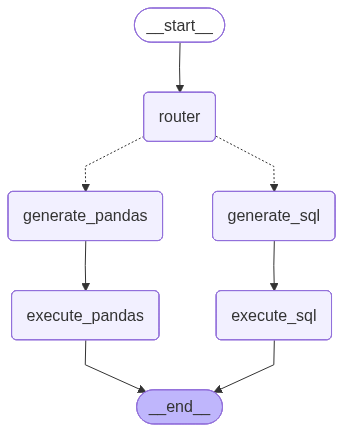

In [ ]:
from typing import TypedDict, Annotated, Literal

import sqlite3
import re
import textwrap
import pandas as pd

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from utils import draw_graph
from data_backends import DB_PATH, ALL_PANDAS_DFS, DATA_SOURCE_REGISTRY, SQL_SCHEMA, PANDAS_CONTEXT


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_query: str
    domain: Literal["SQL", "Pandas"]
    generated_code: str | None
    answer: str | None
    raw_result: str | None
    error: str | None

#Router 
router_model = ChatOllama(model="phi4-mini:latest", temperature=0.0)
router_prompt = SystemMessage(
        "You are a routing agent. Decide which backend to use.\n"
        "- SQL   → data lives in SQLite (MovieLens: movies, ratings, tags, links)\n"
        "- Pandas → data lives as DataFrames (Chinook, Northwind)\n"
        "Output exactly one word: SQL or Pandas.")
def router_node(state: State) -> State:
    query_lower = state["user_query"].lower()

    # 1) Deterministic routing based on DATA_SOURCE_REGISTRY (primary)
    for keyword, backend in DATA_SOURCE_REGISTRY.items():
        if keyword in query_lower:
            user_msg = HumanMessage(state["user_query"])
            return {"domain": backend, "messages": [user_msg]}

    # 2) Fallback: ask a small router LLM if ambiguous
    user_msg = HumanMessage(state["user_query"])
    messages = [router_prompt, *state["messages"], user_msg]
    res = router_model.invoke(messages)
    raw = res.content.strip()
    domain: Literal["SQL", "Pandas"] = "SQL" if raw.lower().startswith("sql") else "Pandas"
    return {"domain": domain, "messages": [user_msg, res]}

#SQL part: uses real SQLite schema and DB_PATH
sql_model = ChatOllama(model="llama3.1:latest", temperature=0.1)

text_to_sql_prompt = SystemMessage(
    content=(
        "You are a SQLite expert working on the MovieLens database.\n"
        "- You may freely JOIN any tables in the schema if needed.\n"
        "- Prefer using JOINs instead of subqueries when combining tables.\n"
        "- Use ONLY the tables/columns from the schema below.\n"
        "- Return a single SELECT query (no comments or explanation).\n\n"
        f"Schema:\n{SQL_SCHEMA}"
    ))
def text_to_sql_node(state:State) -> State:
    messages = [text_to_sql_prompt, *state["messages"]]
    res = sql_model.invoke(messages)
    return {"generated_code": res.content,
            #update conversation history
            "messages": [res],
            "error": None}

#Pandas part: uses ALL_PANDAS_DFS via dfs dict
pandas_model = ChatOllama(model="llama3.1:latest", temperature=0.1)

text_to_pandas_prompt = SystemMessage(
    content=(
        "You are a Pandas expert.\n"
        "- The tables for this dataset are loaded as DataFrames in a dict `dfs`.\n"
        "- You may merge/join multiple DataFrames when needed to answer the question.\n"
        "- Use dfs['table_name'] according to the context below.\n"
        "- Assign your final answer to a variable named `result`.\n"
        "- Return ONLY raw Python code (no ``` fences, no explanation).\n\n"
        f"{PANDAS_CONTEXT}"
    ))
def text_to_pandas_node(state:State) -> State:
    messages = [text_to_pandas_prompt, *state["messages"]]
    res = pandas_model.invoke(messages)
    return {"generated_code": res.content,
            #update conversation history
            "messages": [res],
            "error": None}

# --------------- Helpers for execution --------------------------------
def _strip_fences(code: str) -> str:
    """Remove ```sql / ```python / ``` from LLM output, just in case."""
    return re.sub(r"```[a-zA-Z]*\n?|```", "", code).strip()


def execute_sql_node(state: State) -> State:
    sql = _strip_fences(state["generated_code"] or "")
    try:
        conn = sqlite3.connect(DB_PATH)
        df = pd.read_sql_query(sql, conn)
        conn.close()
        text = df.to_string(index=False)
        return {"raw_result": text, "answer": text, "error": None}
    except Exception as exc:
        return {"error": str(exc), "raw_result": None, "answer": None}


def execute_pandas_node(state: State) -> State:
    code = _strip_fences(state["generated_code"] or "")
    local_ns = {"dfs": ALL_PANDAS_DFS, "pd": pd}
    try:
        exec(textwrap.dedent(code), local_ns)  # noqa: S102
        result = local_ns.get("result", "No `result` variable assigned.")
        return {"raw_result": str(result), "answer": str(result), "error": None}
    except Exception as exc:
        return {"error": str(exc), "raw_result": None, "answer": None}

# ----- Routing function for conditional edges -----
def route_domain(state: State) -> Literal["generate_sql", "generate_pandas"]:
    return "generate_sql" if state["domain"] == "SQL" else "generate_pandas"

# Graph assembly
builder = StateGraph(State)

builder.add_node("router", router_node)
builder.add_node("generate_sql", text_to_sql_node)
builder.add_node("generate_pandas", text_to_pandas_node)
builder.add_node("execute_sql", execute_sql_node)
builder.add_node("execute_pandas", execute_pandas_node)

builder.add_edge(START, "router")
builder.add_conditional_edges("router", route_domain)

# Generation → execution → END
builder.add_edge("generate_sql", "execute_sql")
builder.add_edge("execute_sql", END)

builder.add_edge("generate_pandas", "execute_pandas")
builder.add_edge("execute_pandas", END)

graph = builder.compile()

#Draw the graph
draw_graph(graph)

In [10]:
# Example: 
initial_state = {
    "user_query": "In MovieLens, which 5 movies have the highest average rating among movies with at least 100 ratings?"}

result = graph.invoke(initial_state)
print("Domain:", result["domain"])
print("Generated code:\n", result["generated_code"])

Domain: SQL
Generated code:
 SELECT T1.title FROM movies AS T1 INNER JOIN ratings AS T2 ON T1.movieId = T2.movieId GROUP BY T1.movieId ORDER BY AVG(T2.rating) DESC LIMIT 5


## 3- Validate the generated code(SQL/Pandas)

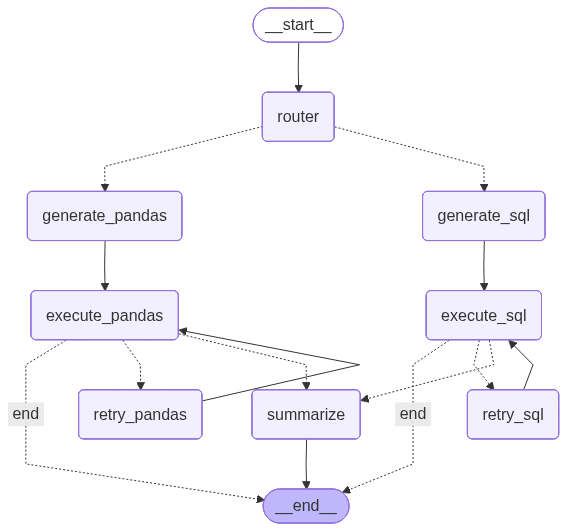

In [12]:
from typing import TypedDict, Annotated, Literal

import sqlite3
import re
import textwrap
import pandas as pd

from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage, AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from utils import draw_graph
from data_backends import DB_PATH, ALL_PANDAS_DFS, DATA_SOURCE_REGISTRY, SQL_SCHEMA, PANDAS_CONTEXT


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_query: str
    domain: Literal["SQL", "Pandas"]
    generated_code: str | None
    answer: str | None
    raw_result: str | None
    error: str | None
    retry_count: int

#Router 
router_model = ChatOllama(model="phi4-mini:latest", temperature=0.0)
router_prompt = SystemMessage(
        "You are a routing agent. Decide which backend to use.\n"
        "- SQL   → data lives in SQLite (MovieLens: movies, ratings, tags, links)\n"
        "- Pandas → data lives as DataFrames (Chinook, Northwind)\n"
        "Output exactly one word: SQL or Pandas.")
def router_node(state: State) -> State:
    query_lower = state["user_query"].lower()

    # 1) Deterministic routing based on DATA_SOURCE_REGISTRY (primary)
    for keyword, backend in DATA_SOURCE_REGISTRY.items():
        if keyword in query_lower:
            user_msg = HumanMessage(state["user_query"])
            return {"domain": backend, "messages": [user_msg]}

    # 2) Fallback: ask a small router LLM if ambiguous
    user_msg = HumanMessage(state["user_query"])
    messages = [router_prompt, *state["messages"], user_msg]
    res = router_model.invoke(messages)
    raw = res.content.strip()
    domain: Literal["SQL", "Pandas"] = "SQL" if raw.lower().startswith("sql") else "Pandas"
    return {"domain": domain, "messages": [user_msg, res]}

#SQL part: uses real SQLite schema and DB_PATH
sql_model = ChatOllama(model="llama3.1:latest", temperature=0.1)

text_to_sql_prompt = SystemMessage(
    "You are a SQLite expert.\n"
    "- You may freely JOIN any tables in the schema if needed.\n"
    "- If the question involves information from multiple tables, "
    "you MUST use appropriate JOINs.\n"
    "- Prefer explicit JOINs over subqueries.\n"
    "- Use ONLY the tables/columns from the schema below.\n"
    "- Return a single SELECT query (no comments or explanation).\n\n"
    f"Schema:\n{SQL_SCHEMA}")

def text_to_sql_node(state:State) -> State:
    messages = [text_to_sql_prompt, *state["messages"]]
    res = sql_model.invoke(messages)
    return {"generated_code": res.content,
            #update conversation history
            "messages": [res],
            "error": None}

#Pandas part: uses ALL_PANDAS_DFS via dfs dict
pandas_model = ChatOllama(model="llama3.1:latest", temperature=0.1)

text_to_pandas_prompt = SystemMessage(
    content=(
        "You are a Pandas expert.\n"
        "- The tables for this dataset are loaded as DataFrames in a dict `dfs`.\n"
        "- You may merge/join multiple DataFrames when needed to answer the question.\n"
        "- Use dfs['table_name'] according to the context below.\n"
        "- Assign your final answer to a variable named `result`.\n"
        "- Return ONLY raw Python code (no ``` fences, no explanation).\n\n"
        f"{PANDAS_CONTEXT}"
    ))
def text_to_pandas_node(state:State) -> State:
    messages = [text_to_pandas_prompt, *state["messages"]]
    res = pandas_model.invoke(messages)
    return {"generated_code": res.content,
            #update conversation history
            "messages": [res],
            "error": None}

# --------------- Helpers for execution --------------------------------
def _strip_fences(code: str) -> str:
    """Remove ```sql / ```python / ``` from LLM output, just in case."""
    return re.sub(r"```[a-zA-Z]*\n?|```", "", code).strip()


def run_sql_locally(sql: str) -> str:
    """Run a SQL query on the local SQLite DB and return a stringified DataFrame."""
    conn = sqlite3.connect(DB_PATH)
    try:
        df = pd.read_sql_query(sql, conn)
    finally:
        conn.close()
    return df.to_string(index=False)


def run_pandas_locally(code: str) -> str:
    """
    Execute generated Pandas code against ALL_PANDAS_DFS and
    return the string representation of result.
    """
    local_ns = {"dfs": ALL_PANDAS_DFS, "pd": pd}
    exec(textwrap.dedent(code), local_ns)  # noqa: S102
    result = local_ns.get("result", "No `result` variable assigned.")
    return str(result)

def execute_sql_node(state: State) -> State:
    sql = _strip_fences(state["generated_code"] or "")
    try:
        text = run_sql_locally(sql)
        return {"raw_result": text, "answer": text, "error": None}
    except Exception as exc:
        return {"error": str(exc), "raw_result": None, "answer": None}


def execute_pandas_node(state: State) -> State:
    code = _strip_fences(state["generated_code"] or "")
    try:
        text = run_pandas_locally(code)
        return {"raw_result": text, "answer": text, "error": None}
    except Exception as exc:
        return {"error": str(exc), "raw_result": None, "answer": None}
    
MAX_RETRIES = 2

def route_after_exec(state: State) -> Literal["retry_sql", "retry_pandas", "summarize", "end"]:
    # if there was an error and we still have retries left → retry
    if state.get("error") and state.get("retry_count", 0) < MAX_RETRIES:
        return "retry_sql" if state["domain"] == "SQL" else "retry_pandas"
    # if there was an error and we've exhausted retries → end
    if state.get("error"):
        return "end"
    # success → summarize
    return "summarize"

def retry_text_to_sql_node(state: State) -> State:
    error_hint = f"\nThe previous SQL failed with error:\n{state['error']}\n"
    messages = [
        SystemMessage(text_to_sql_prompt.content + error_hint),
        *state["messages"],
    ]
    res = sql_model.invoke(messages)
    return {
        "generated_code": res.content,
        "messages": [res],
        "error": None,
        "retry_count": state.get("retry_count", 0) + 1,
    }

def retry_text_to_pandas_node(state: State) -> State:
    error_hint = f"\nThe previous Pandas code failed with error:\n{state['error']}\n"
    messages = [
        SystemMessage(text_to_pandas_prompt.content + error_hint),
        *state["messages"],
    ]
    res = pandas_model.invoke(messages)
    return {
        "generated_code": res.content,
        "messages": [res],
        "error": None,
        "retry_count": state.get("retry_count", 0) + 1,
    }

answer_model = ChatOllama(model="llama3.1:latest", temperature=0.1)

answer_prompt = SystemMessage(
    "You are a data analyst.\n"
    "Given the user question and a tabular/text result, "
    "write a concise answer in 2–5 sentences. "
    "If the result is a table, summarize the key numbers."
)

def summarize_node(state: State) -> State:
    user = HumanMessage(
        f"User question:\n{state['user_query']}\n\nRaw result:\n{state['raw_result']}"
    )
    res = answer_model.invoke([answer_prompt, user])
    return {"answer": res.content, "messages": [res]}

# ----- Routing function for conditional edges -----
def route_domain(state: State) -> Literal["generate_sql", "generate_pandas"]:
    return "generate_sql" if state["domain"] == "SQL" else "generate_pandas"

# Graph assembly
builder = StateGraph(State)

builder.add_node("router", router_node)
builder.add_node("generate_sql", text_to_sql_node)
builder.add_node("generate_pandas", text_to_pandas_node)
builder.add_node("execute_sql", execute_sql_node)
builder.add_node("execute_pandas", execute_pandas_node)
builder.add_node("retry_sql", retry_text_to_sql_node)
builder.add_node("retry_pandas", retry_text_to_pandas_node)
builder.add_node("summarize", summarize_node)


builder.add_edge(START, "router")
builder.add_conditional_edges("router", route_domain)

#Generation → execution → summarize/end with retries in between
builder.add_edge("generate_sql", "execute_sql")
builder.add_conditional_edges(
    "execute_sql",
    route_after_exec,
    {"retry_sql": "retry_sql", "summarize": "summarize", "end": END},
)
builder.add_edge("retry_sql", "execute_sql")

builder.add_edge("generate_pandas", "execute_pandas")
builder.add_conditional_edges(
    "execute_pandas",
    route_after_exec,
    {"retry_pandas": "retry_pandas", "summarize": "summarize", "end": END},
)
builder.add_edge("retry_pandas", "execute_pandas")

builder.add_edge("summarize", END)

graph = builder.compile()

#Draw the graph
draw_graph(graph)

In [14]:
initial_state: State = {
    "messages": [],
    "user_query": "Which 5 products have the highest total quantity sold?",
    "domain": "SQL",   # placeholder; router_node will overwrite
    "generated_code": None,
    "answer": None,
    "raw_result": None,
    "error": None,
    "retry_count": 0,
}

final_state = graph.invoke(initial_state)
print("Domain:", final_state["domain"])
print("Answer:", final_state["answer"])
print("Raw result:\n", final_state["raw_result"])

Domain: Pandas
Answer: The top 5 products with the highest total quantity sold are:

1. Product ID 60 - 1577 units
2. Product ID 59 - 1496 units
3. Product ID 31 - 1397 units
4. Product ID 56 - 1263 units
5. Product ID 16 - 1158 units
Raw result:
 productid
60    1577
59    1496
31    1397
56    1263
16    1158
Name: quantity, dtype: int64
